In [ ]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_alpha_sweep_specific_norm,
    plot_performance_vs_consistency_per_perturbation_strength,

)

INFO: P [MainThread] 2025-08-15 17:04:40,595 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


Processing augmentation: a001-a003
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


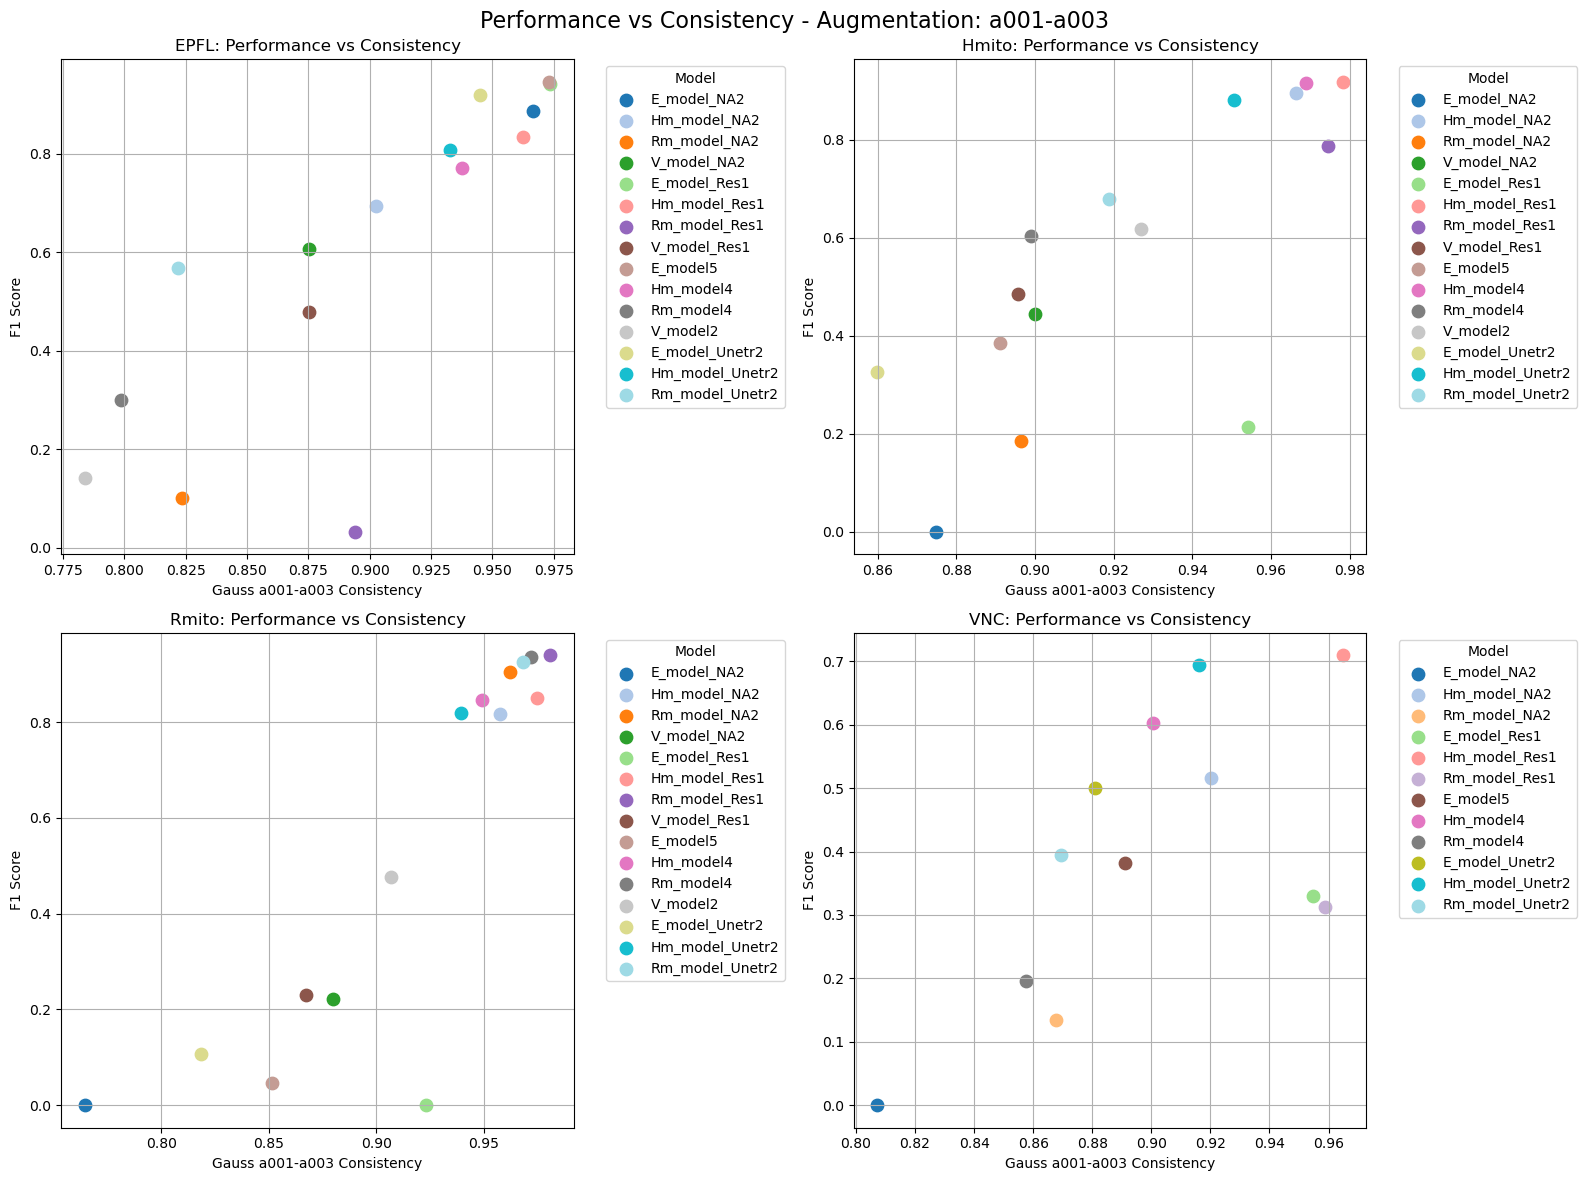

Processing augmentation: a003-a005
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


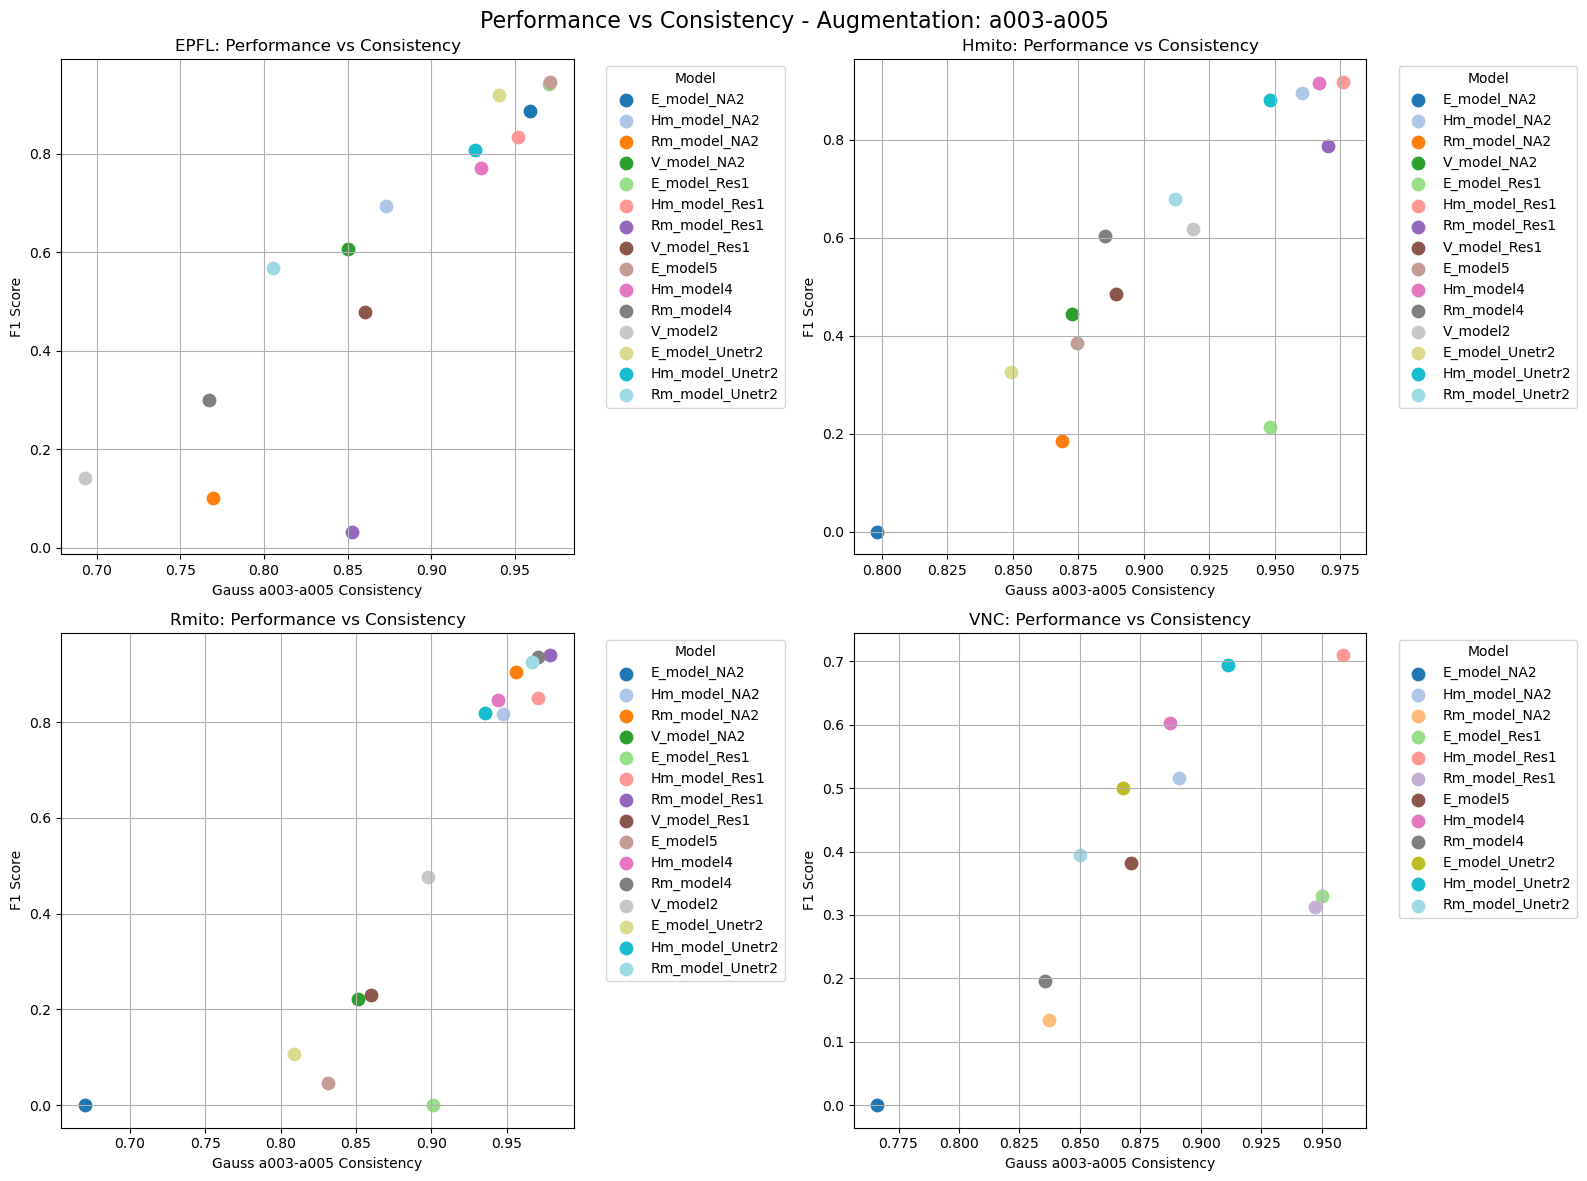

Processing augmentation: a005-a007
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


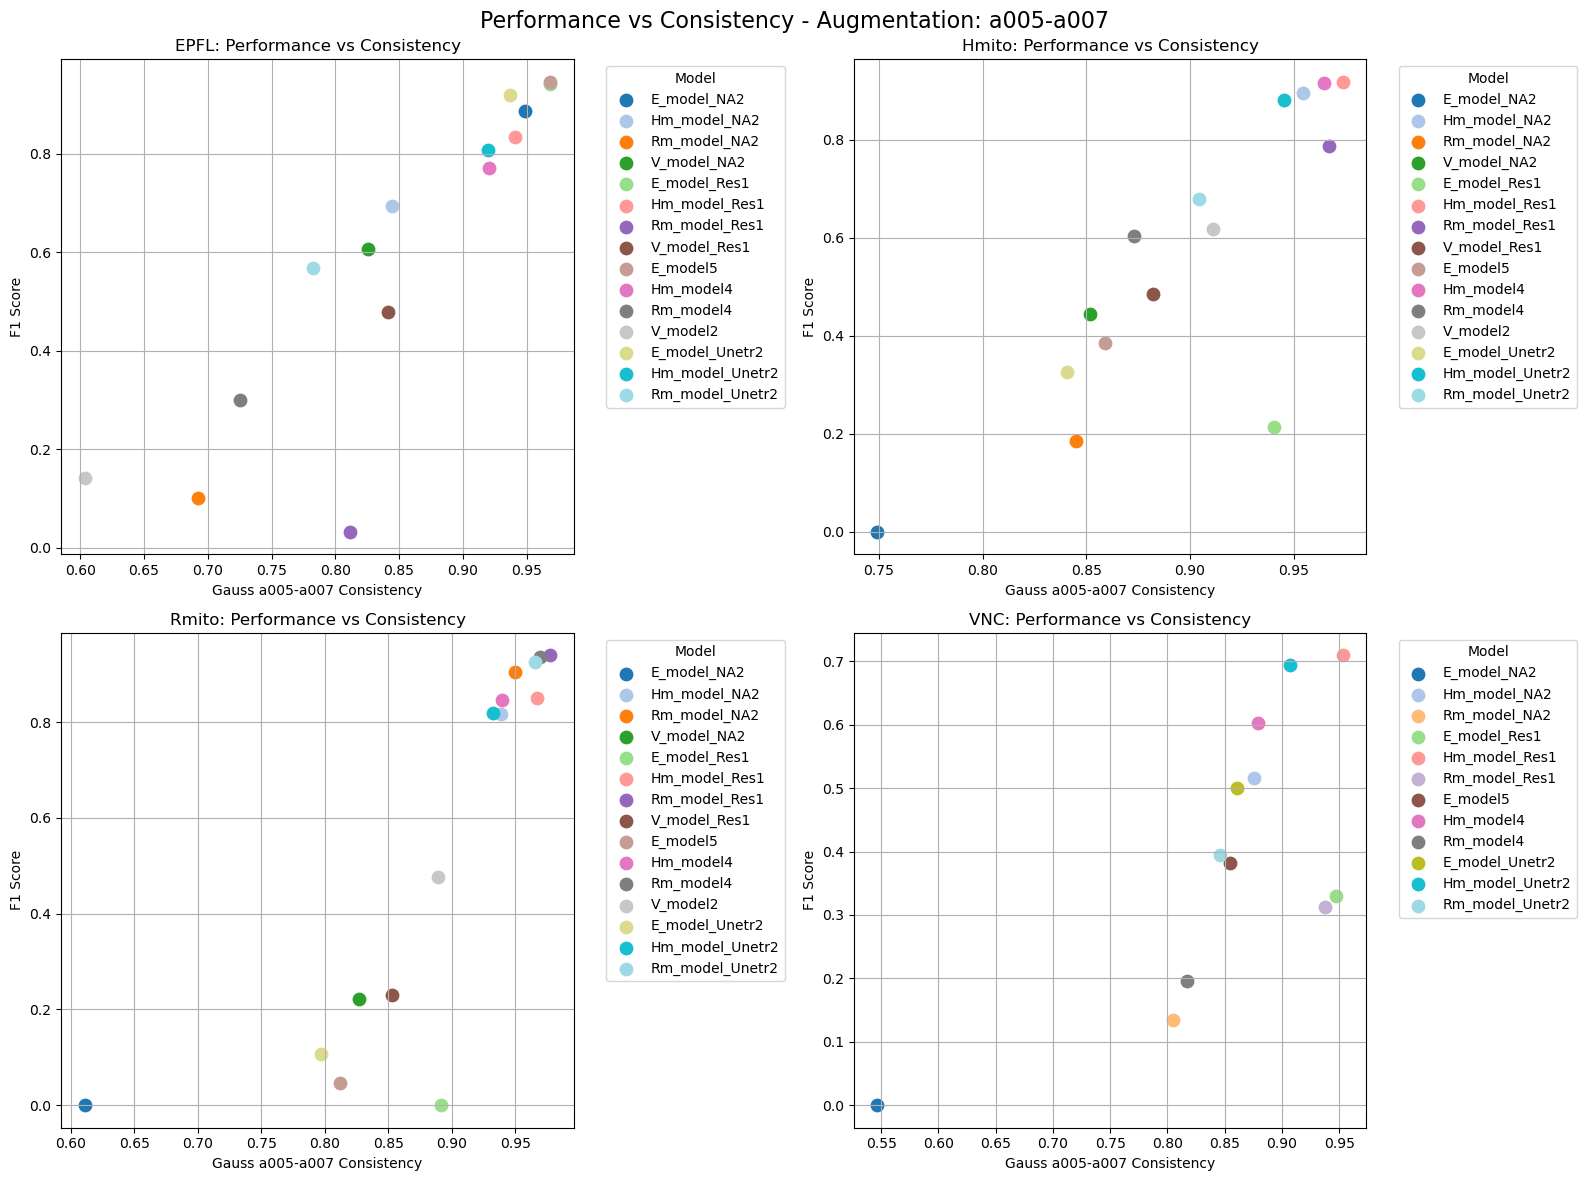

Processing augmentation: a007-a01
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


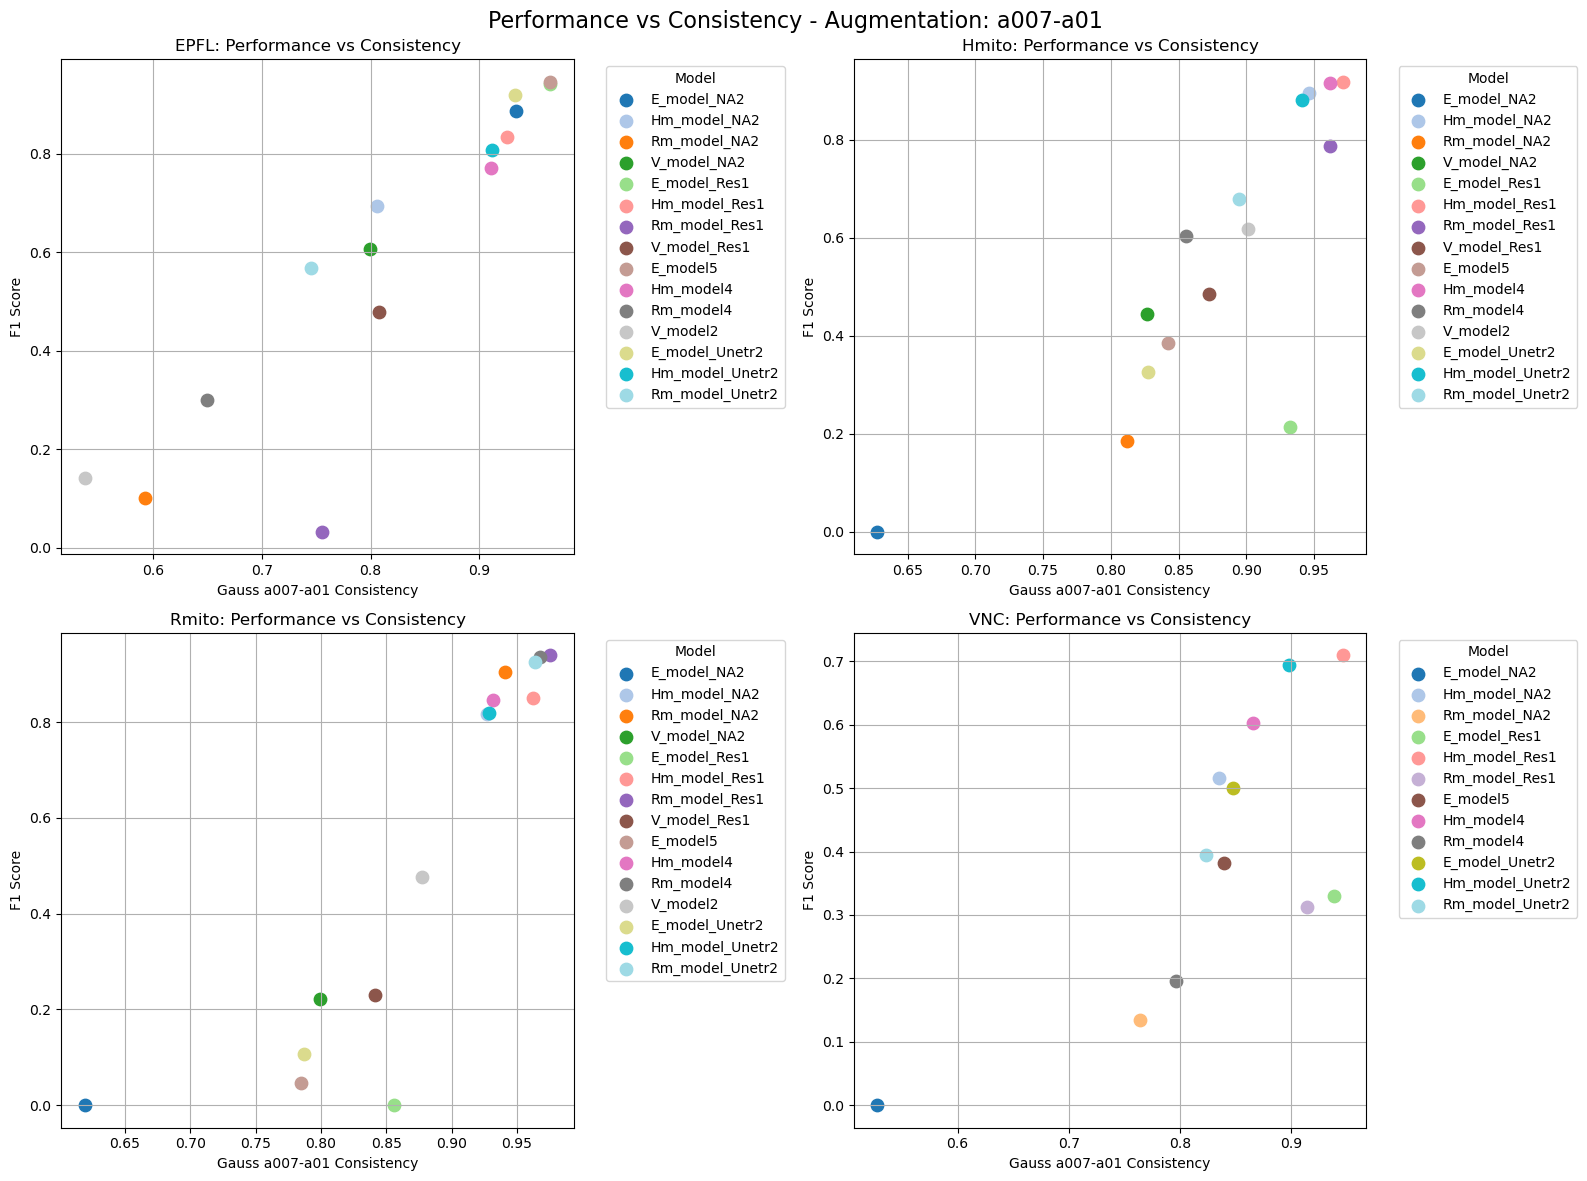

Processing augmentation: a01-a02
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


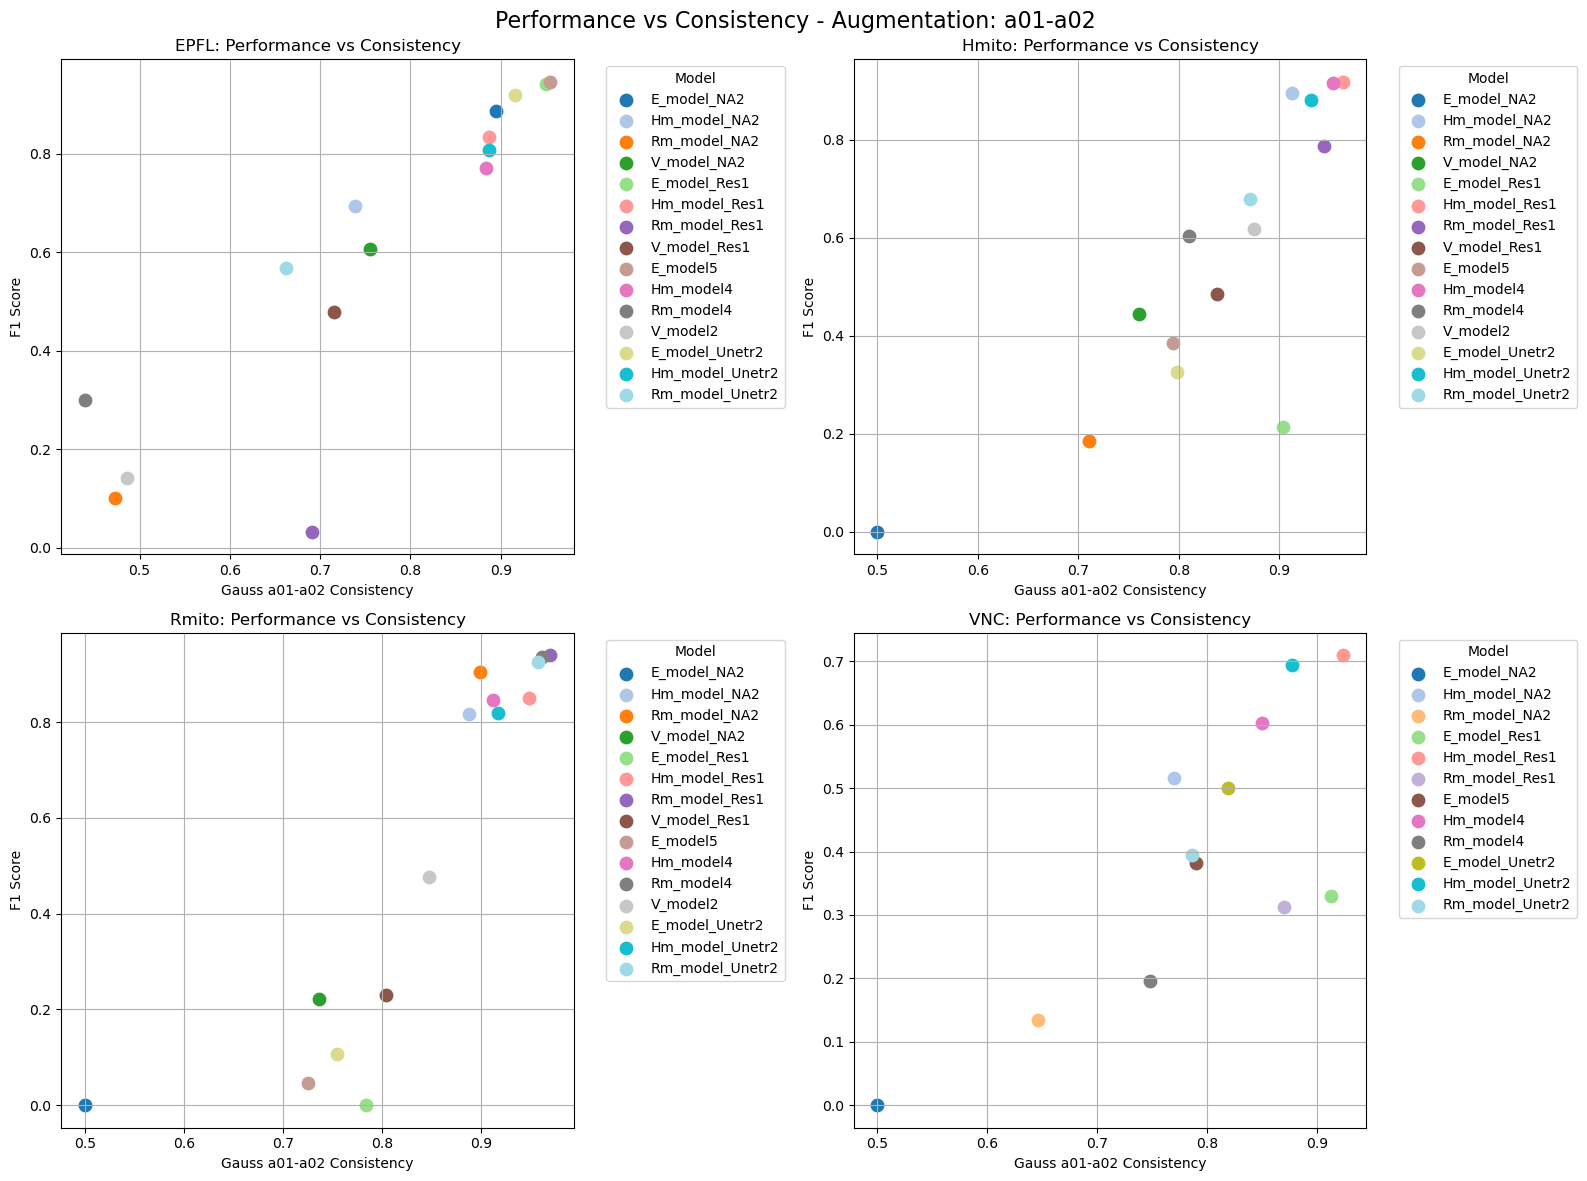

In [3]:
import matplotlib.pyplot as plt

base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency"
selected_augmentations = ["a001-a003", "a003-a005", "a005-a007", "a007-a01", "a01-a02"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}__AllLayers_CMB_05f_05b_consistency_scores.json"
    consistency_path = Path(base_path) / file_name
    with open(consistency_path, "r") as f:
        consistency_scores = json.load(f)["transfer_scores"]
        plot_performance_vs_consistency_per_perturbation_strength(
            performance_scores=performance_scores,
            consistency_scores=consistency_scores,
            aug=aug,
        )
        
        

# Combined Plot

In [4]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores_with_NORM.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


In [5]:
consistency_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_GaussSweep_AllLayers_CMB_05f_05b_consistency_scores_with_NORM.json"
with open(consistency_path, "r") as f:
    consistency_scores = json.load(f)["transfer_scores"]

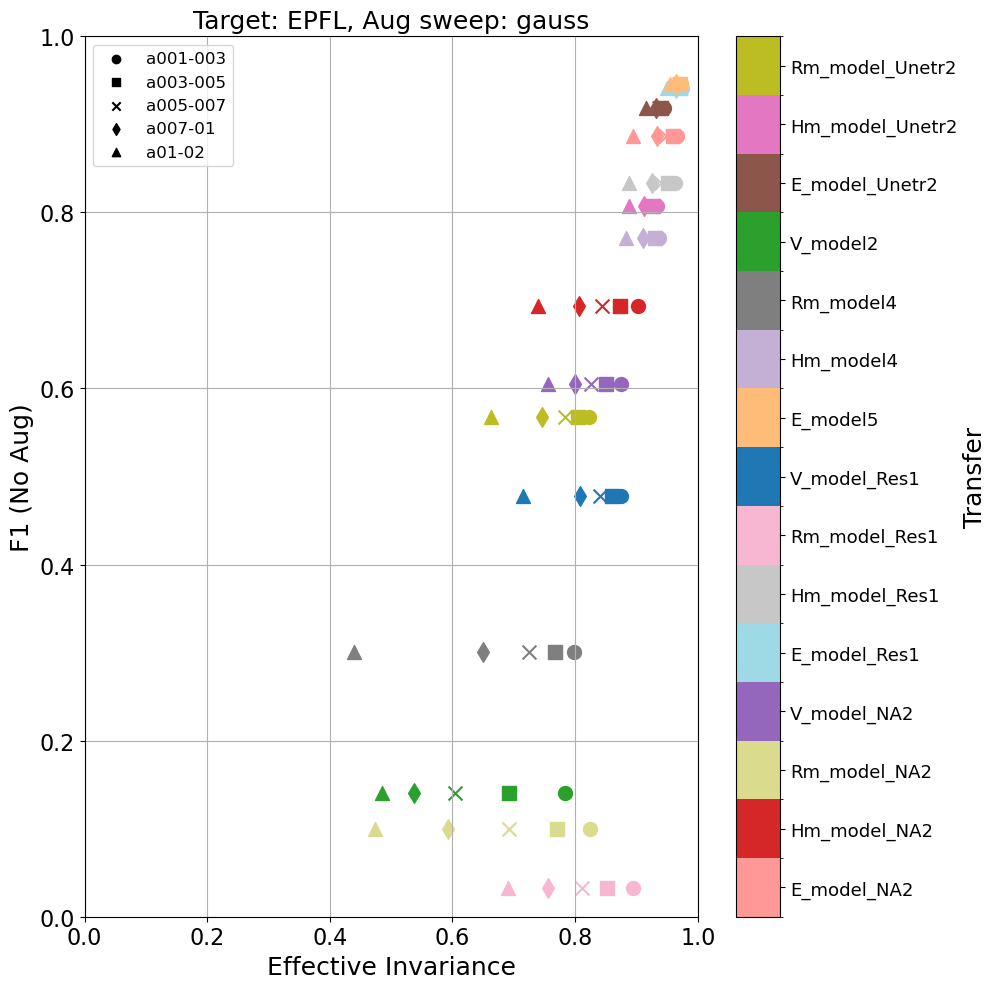

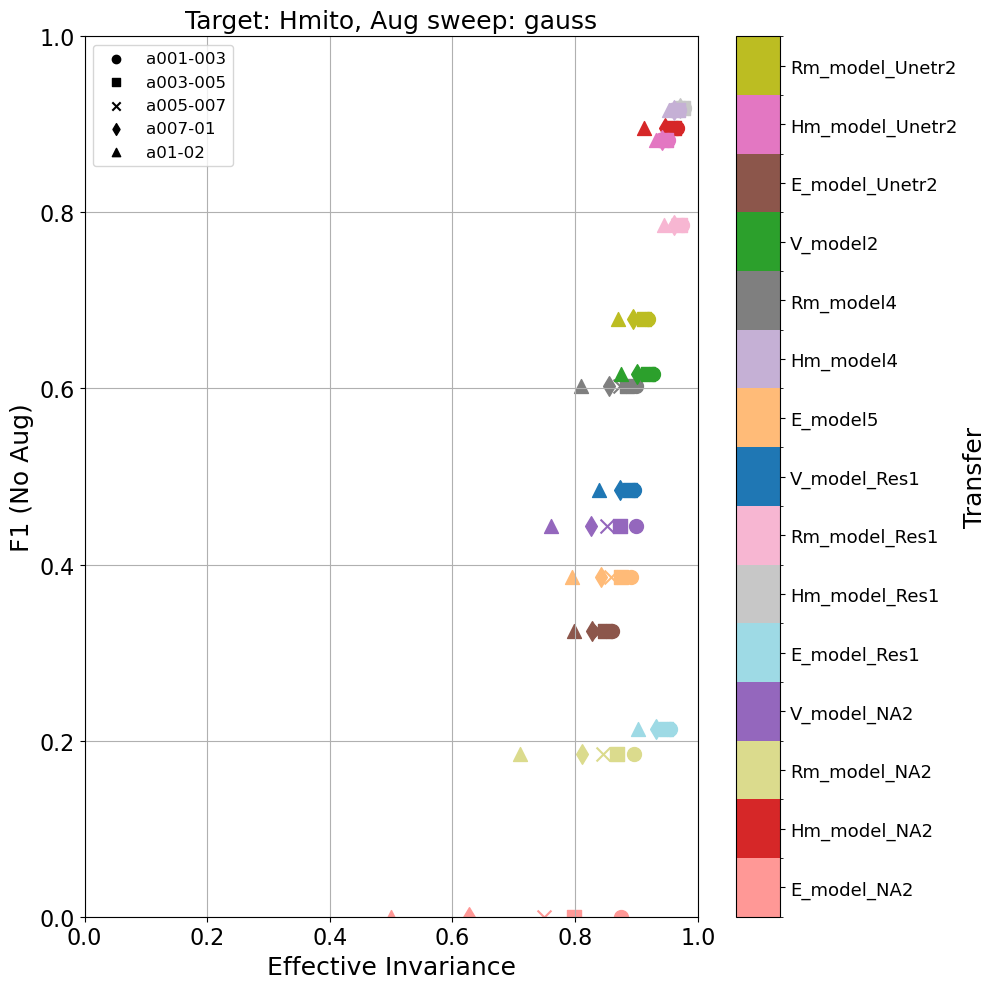

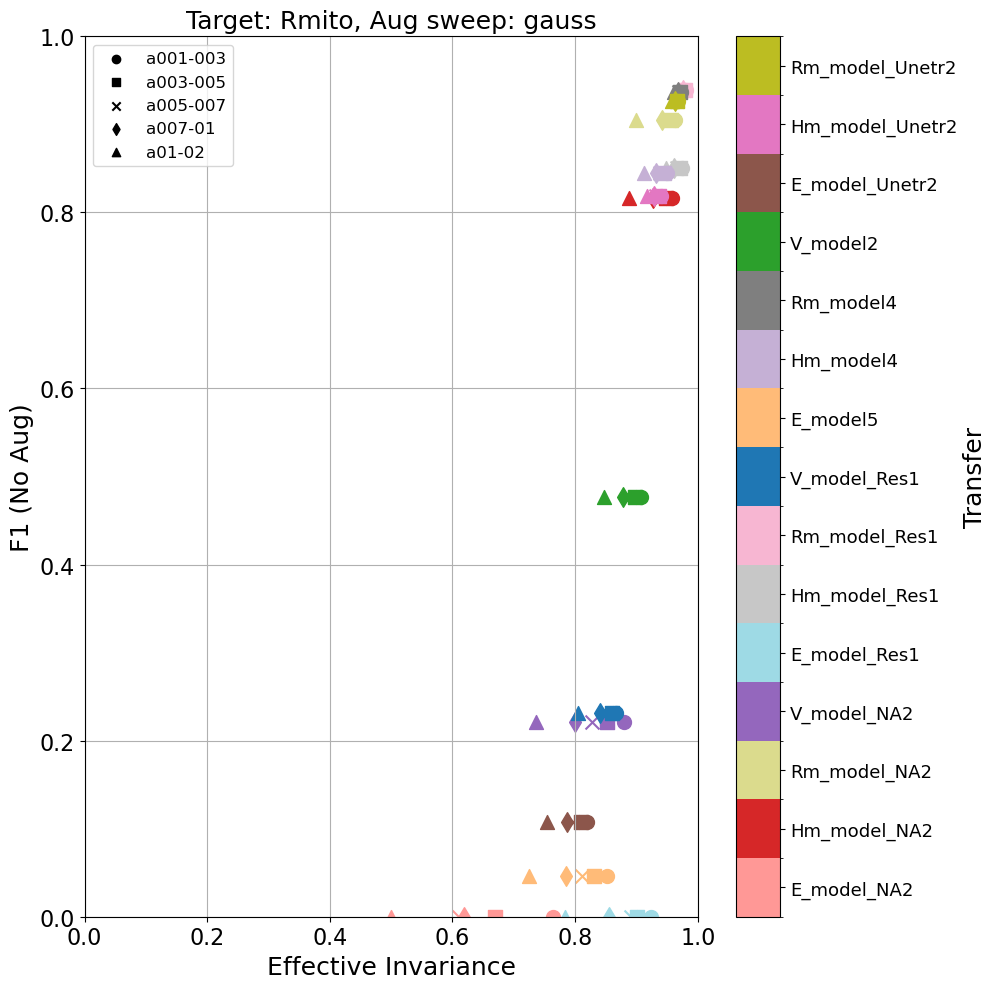

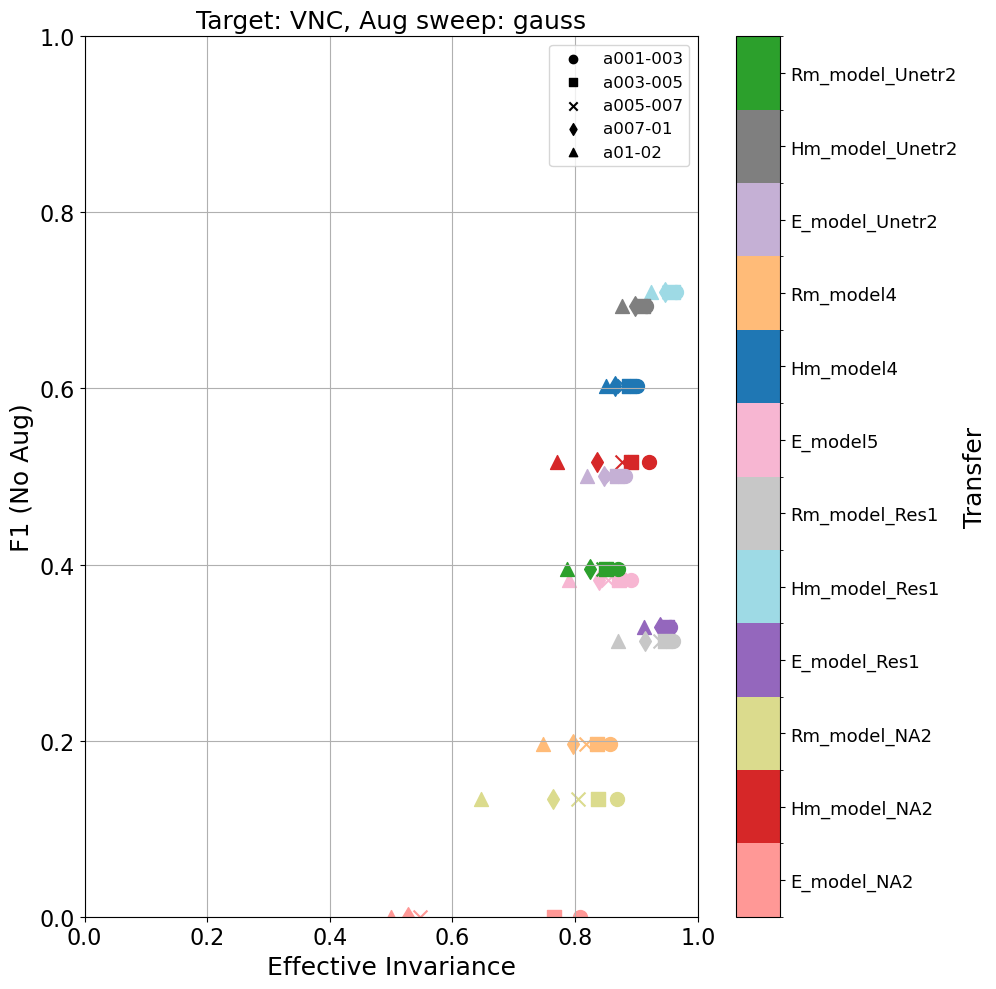

In [6]:
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-02"],
}
per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

for target in consistency_scores.keys():
    plot_alpha_sweep_specific_norm(
        consistency_scores[target],
        performance_scores[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )